In [1]:
# Instalações necessárias
!pip install transformers torch scikit-learn pandas spacy nltk matplotlib seaborn
!python -m spacy download pt_core_news_lg

import nltk
nltk.download('stopwords')
nltk.download('punkt')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 2.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
!pip install datasets

In [7]:
import pandas as pd

print("Carregando o seu arquivo local de Hate Speech...")

# Substitua pelo caminho real onde o arquivo está salvo (ex: no Google Colab, se você arrastar para a pasta, fica assim)
caminho_arquivo = "2019-05-28_portuguese_hate_speech_hierarchical_classification.csv"

# Lendo o arquivo CSV direto do seu ambiente
df = pd.read_csv(caminho_arquivo)

# Esse dataset específico usa a coluna 'Hate.speech' (com ponto) para indicar 0 ou 1
# Vamos renomeá-la para 'label' para manter o padrão do seu pipeline anterior
df['label'] = df['Hate.speech']

# Ajustar o nome da coluna de texto (que já se chama 'text') e remover nulos/duplicados
df['text'] = df['text'].fillna('').astype(str).str.strip()
df = df.drop_duplicates(subset=['text']).copy()

# Filtrar textos muito curtos
df['qtd_palavras'] = df['text'].apply(lambda x: len(x.split()))
df_limpo = df[df['qtd_palavras'] > 2].copy()

print(f"\nTotal de registros carregados com sucesso: {len(df_limpo)}")
print("\nExemplo dos dados carregados prósperos:")
print(df_limpo[['text', 'label']].head())

Carregando o seu arquivo local de Hate Speech...

Total de registros carregados com sucesso: 5668

Exemplo dos dados carregados prósperos:
                                                text  label
0                   "não come mel, morde marimbondo"      0
1                       não tem pinto, tem orgulho !      0
2  Não vê essa merda de Crepúsculo! Pra isso temo...      0
3  não da tapa na bundinha, da cotovelada nas cos...      0
4  o diminutivo INHO não acompanha a trajetória d...      1


In [8]:
from nltk.corpus import stopwords
import re

stop_words_pt = set(stopwords.words('portuguese'))
# Evite colocar palavras expressivas ou gírias comuns aqui para não perder o contexto do ódio

def limpar_texto_hate_speech(texto):
    texto = str(texto).lower()
    # Mantém letras e links/hashtags se achar relevante, ou limpa mantendo acentos:
    texto = re.sub(r'[^a-záéíóúâêôãõç\s]', ' ', texto)

    palavras = texto.split()
    palavras_limpas = [p for p in palavras if p not in stop_words_pt and len(p) > 2]
    return " ".join(palavras_limpas)

df_limpo['texto_limpo'] = df_limpo['text'].apply(limpar_texto_hate_speech)

In [9]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de processamento: {device}")

nome_modelo = 'neuralmind/bert-base-portuguese-cased'
tokenizer = AutoTokenizer.from_pretrained(nome_modelo)
modelo_bert = AutoModel.from_pretrained(nome_modelo).to(device)

def extrair_embeddings(texto):
    # Trunca em 128 ou 256 já que posts de internet costumam ser curtos
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = modelo_bert(**inputs)

    # Média dos embeddings das palavras para gerar o vetor do texto
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embeddings.cpu().numpy()

print("Gerando Embeddings para as mensagens...")
df_limpo['embeddings'] = df_limpo['text'].apply(extrair_embeddings)
print("Embeddings gerados!")

Dispositivo de processamento: cuda


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando Embeddings para as mensagens...
Embeddings gerados!


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Preparar a matriz de recursos (X) e o alvo (y)
X = np.vstack(df_limpo['embeddings'].values)
y = df_limpo['label'].values # Substitua 'label' pelo nome da sua coluna de alvos (0 ou 1)

# Dividir em Treino e Teste (80% treino, 20% teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Treinar um classificador clássico usando os embeddings do BERT
print("Treinando o classificador...")
classificador = LogisticRegression(max_iter=1000)
classificador.fit(X_treino, y_treino)

# Avaliação do modelo
predicoes = classificador.predict(X_teste)
print("\n--- Relatório de Classificação ---")
print(classification_report(y_teste, predicoes))

Treinando o classificador...

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       888
           1       0.71      0.51      0.59       246

    accuracy                           0.85      1134
   macro avg       0.79      0.72      0.75      1134
weighted avg       0.84      0.85      0.84      1134



Gerando o t-SNE para visualização das classes...


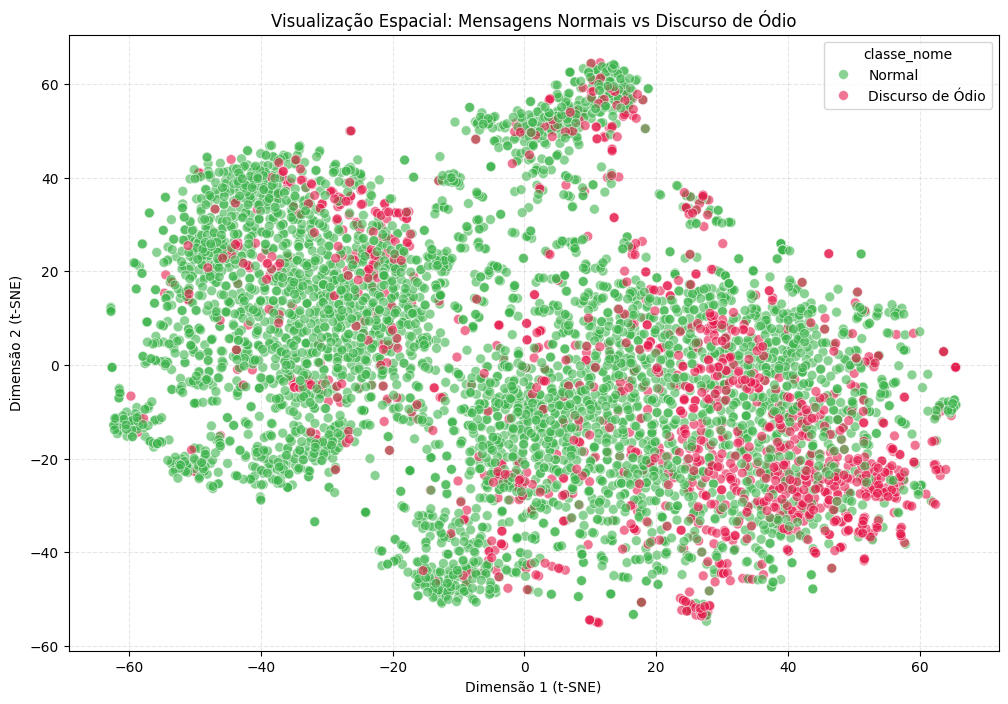

In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("Gerando o t-SNE para visualização das classes...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
pontos_2d = tsne.fit_transform(X)

df_limpo['tsne_1'] = pontos_2d[:, 0]
df_limpo['tsne_2'] = pontos_2d[:, 1]

# Mapear os nomes para a legenda do gráfico
mapeamento_nomes = {0: "Normal", 1: "Discurso de Ódio"}
df_limpo['classe_nome'] = df_limpo['label'].map(mapeamento_nomes)

# Plotando o Gráfico
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='classe_nome',
    palette=['#3cb44b', '#e6194b'], # Verde para normal, Vermelho para ódio
    data=df_limpo,
    alpha=0.6, s=50
)

plt.xlabel("Dimensão 1 (t-SNE)")
plt.ylabel("Dimensão 2 (t-SNE)")
plt.title("Visualização Espacial: Mensagens Normais vs Discurso de Ódio")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

/tmp/ipykernel_2772/1099560526.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=soma_categorias.values, y=soma_categorias.index, palette='viridis')


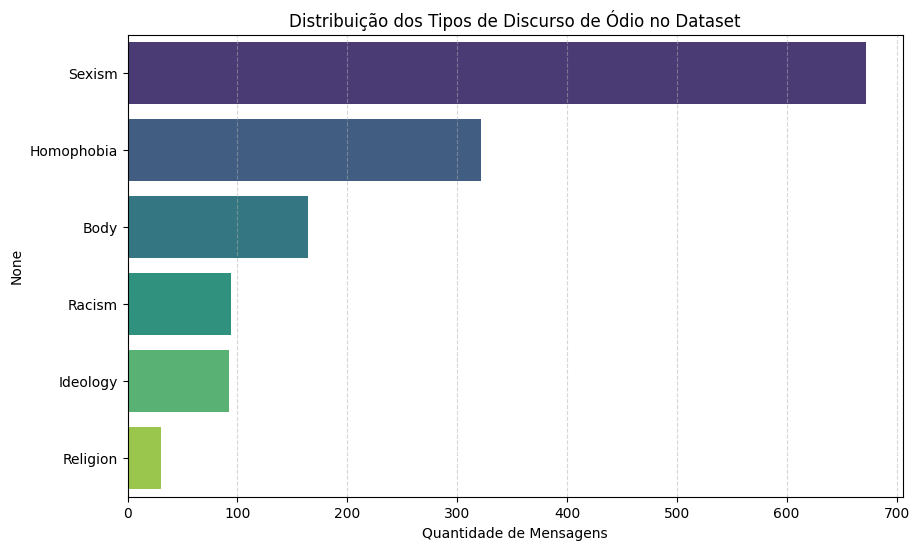

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar as colunas de categorias (remover 'text' e 'Hate.speech')
colunas_categorias = ['Sexism', 'Body', 'Racism', 'Ideology', 'Homophobia', 'Religion']

# Somar a quantidade de ocorrências de cada tipo
soma_categorias = df_limpo[colunas_categorias].sum().sort_values(ascending=False)

# Criar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=soma_categorias.values, y=soma_categorias.index, palette='viridis')

plt.xlabel('Quantidade de Mensagens')
plt.title('Distribuição dos Tipos de Discurso de Ódio no Dataset')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

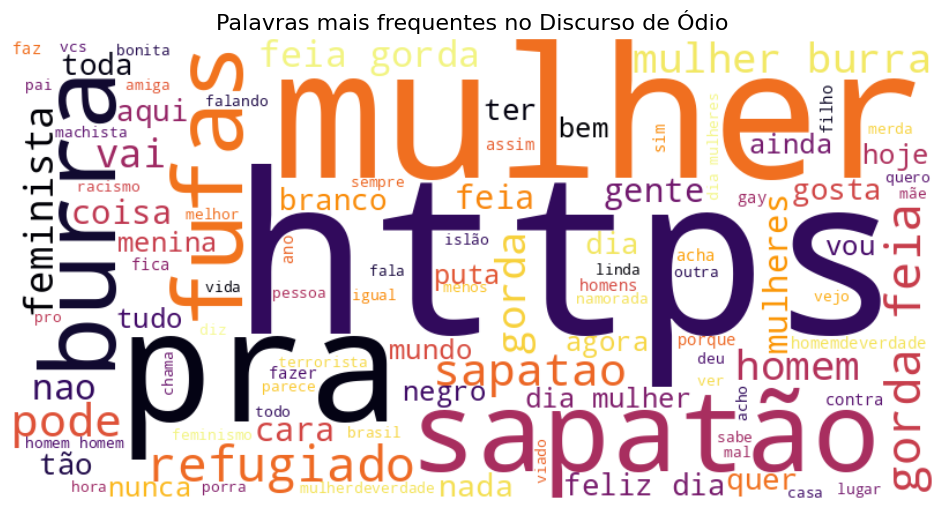

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtrar apenas os textos que foram rotulados como ódio (label == 1)
textos_odio = " ".join(df_limpo[df_limpo['label'] == 1]['texto_limpo'])

# Configurar a Nuvem de Palavras
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='inferno',
                      max_words=100).generate(textos_odio)

# Exibir a imagem
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras mais frequentes no Discurso de Ódio', fontsize=16)
plt.show()

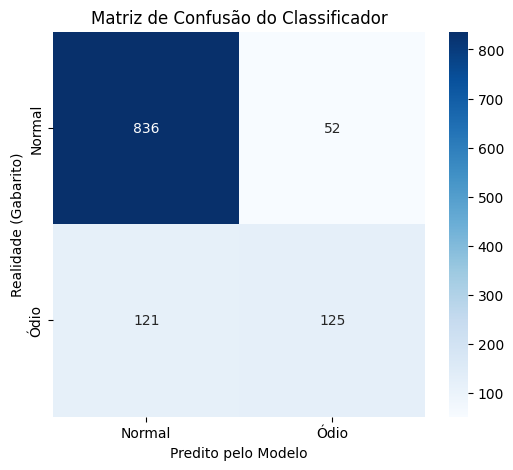

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gerar a matriz numérica
cm = confusion_matrix(y_teste, predicoes)

# Plotar graficamente
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ódio'],
            yticklabels=['Normal', 'Ódio'])

plt.xlabel('Predito pelo Modelo')
plt.ylabel('Realidade (Gabarito)')
plt.title('Matriz de Confusão do Classificador')
plt.show()